# Lending Club Loan Data Analysis

* *Course-end Project 3*

## Description

* _Create a model that predicts whether or not a loan will be default using the historical data._

### Problem Statement:  

For companies like Lending Club correctly predicting whether or not a loan will be a default is very important. In this project, using the historical data from 2007 to 2015, you have to build a deep learning model to predict the chance of default for future loans. As you will see later this dataset is highly imbalanced and includes a lot of features that make this problem more challenging.

* Domain: Finance

* Analysis to be done: Perform data preprocessing and build a deep learning prediction model. 

### Content: 

* Dataset columns and definition:

 

1. **_credit.policy_**        : 1 if the customer meets the credit underwriting criteria of LendingClub.com, and 0 otherwise.

2. **_purpose_**              : The purpose of the loan (takes values "credit_card", "debt_consolidation", "educational", "major_purchase", "small_business", and "all_other").

3. **_int.rate_**             : The interest rate of the loan, as a proportion (a rate of 11% would be stored as 0.11). Borrowers judged by LendingClub.com to be more risky are assigned higher interest rates.

4. **_installment_**          : The monthly installments owed by the borrower if the loan is funded.

5. **_log.annual.inc_**       : The natural log of the self-reported annual income of the borrower.

6. **_dti_**                  : The debt-to-income ratio of the borrower (amount of debt divided by annual income).

7. **_fico_**                 : The FICO credit score of the borrower.

8. **_days.with.cr.line_**    : The number of days the borrower has had a credit line.

9. **_revol.bal_**            : The borrower's revolving balance (amount unpaid at the end of the credit card billing cycle).

10. **_revol.util_**          : The borrower's revolving line utilization rate (the amount of the credit line used relative to total credit available).

11. **_inq.last.6mths_**      : The borrower's number of inquiries by creditors in the last 6 months.

12. **_delinq.2yrs_**         : The number of times the borrower had been 30+ days past due on a payment in the past 2 years.

13. **_pub.rec_**             : The borrower's number of derogatory public records (bankruptcy filings, tax liens, or judgments).

 

## Steps to perform:

Perform exploratory data analysis and feature engineering and then apply feature engineering. Follow up with a deep learning model to predict whether or not the loan will be default using the historical data.

Tasks:

1.     Feature Transformation

    * Transform categorical values into numerical values (discrete)

2.     Exploratory data analysis of different factors of the dataset.

3.     Additional Feature Engineering

    * You will check the correlation between features and will drop those features which have a strong correlation

    * This will help reduce the number of features and will leave you with the most relevant features

4.     Modeling

    * After applying EDA and feature engineering, you are now ready to build the predictive models

    * In this part, you will create a deep learning model using Keras with Tensorflow backend

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import warnings


In [2]:
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE


In [3]:
df = pd.read_csv('loan_data.csv'); df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


In [4]:
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [5]:
df.describe()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000
mean,0.804970,0.122640,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,46.799236,1.577469,0.163708,0.062122,0.160054
std,0.396245,0.026847,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,29.014417,2.200245,0.546215,0.262126,0.366676
min,0.000000,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.600000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.122100,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,46.300000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.140700,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,70.900000,2.000000,0.000000,0.000000,0.000000
max,1.000000,0.216400,940.140000,14.528354,29.960000,827.000000,17639.958330,1.207359e+06,119.000000,33.000000,13.000000,5.000000,1.000000


## Question 2.  **EDA**

* Checking Null Values

In [6]:
df.isna().sum()

credit.policy        0
purpose              0
int.rate             0
installment          0
log.annual.inc       0
dti                  0
fico                 0
days.with.cr.line    0
revol.bal            0
revol.util           0
inq.last.6mths       0
delinq.2yrs          0
pub.rec              0
not.fully.paid       0
dtype: int64

* Checking Duplicates

In [7]:
df.duplicated().sum()

0

* Checking Column Names

In [8]:
df.columns

Index(['credit.policy', 'purpose', 'int.rate', 'installment', 'log.annual.inc',
       'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util',
       'inq.last.6mths', 'delinq.2yrs', 'pub.rec', 'not.fully.paid'],
      dtype='object')

* Replacing the '.' with '_' for ease

In [9]:
df.columns = df.columns.str.replace('.', '_')
df.columns

Index(['credit_policy', 'purpose', 'int_rate', 'installment', 'log_annual_inc',
       'dti', 'fico', 'days_with_cr_line', 'revol_bal', 'revol_util',
       'inq_last_6mths', 'delinq_2yrs', 'pub_rec', 'not_fully_paid'],
      dtype='object')

* Visulaising Distribution

In [10]:
feature_list = df.select_dtypes('number').columns

In [11]:
l = len(feature_list)

row = l // 3 +1

fig = make_subplots(cols = 3,
                    rows = row,
                    subplot_titles=[f'<i>{i.title()}</i>' for i in feature_list])
for i in range(l):
    fig.add_trace(go.Histogram(x = df[feature_list[i]]),
                  col = i //  row +1,
                  row = i % row +1)

fig.update_layout(height = row * 300,
                  width = 1200,
                  title_text = '<b>Feature Distribution',
                  template = 'plotly_dark',
                  title_x = 0.5,
                  showlegend=False)


fig.show()

In [12]:
fig = px.histogram(df,
             x = 'not_fully_paid',
             color = 'not_fully_paid',
             template = 'plotly_dark',
             title = 'Ratio of People with their Loan Not Fully Paid',
             )

fig.update_traces(showlegend =  False)
fig.show()

In [13]:
fig = px.histogram(df,
             y = 'not_fully_paid',
             x = 'purpose',
             color = 'purpose',
             template = 'plotly_dark',
             title = 'Number of People with their Loan Not Fully Paid for different Intrest Rates',
             )

fig.show()

In [14]:
px.scatter(data_frame=df, 
           x = 'revol_util',
           y = 'revol_bal',
           color = 'not_fully_paid')

In [15]:
l = len(feature_list)

row = l // 3 +1

fig = make_subplots(cols = 3,
                    rows = row,
                    subplot_titles=[f'<i>{i.title()}</i>' for i in feature_list])
for i in range(l):
    fig.add_trace(go.Box(x = df[feature_list[i]]),
                  col = i //  row +1,
                  row = i % row +1)

fig.update_layout(height = row * 250,
                  width = 1200,
                  title_text = '<b>Feature Distribution',
                  template = 'plotly_dark',
                  title_x = 0.5,
                  showlegend=False)


fig.show()

* As we see, there are many Outliers in the some of the Columns, so we will check the counts of the Outliers in each variable


## Question 1.     Feature Transformation

    * Transform categorical values into numerical values (discrete)

In [16]:
df['purpose'].value_counts()

purpose
debt_consolidation    3957
all_other             2331
credit_card           1262
home_improvement       629
small_business         619
major_purchase         437
educational            343
Name: count, dtype: int64

In [17]:
df['purpose'] = LabelEncoder().fit_transform(df['purpose']); df.head()

,credit_policy,purpose,int_rate,installment,log_annual_inc,dti,fico,days_with_cr_line,revol_bal,revol_util,inq_last_6mths,delinq_2yrs,pub_rec,not_fully_paid
0,1,2,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,2,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,2,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [18]:
def outliers(col):
    # Defining Quantiles
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    
    IQR = q3-q1   # Getting Inter Quantile Range
    
    # Defining Upper and Lower bouds
    lwr = q1-1.5*IQR
    upr = q3+1.5*IQR
    
    outliers = df[col][((df[col]<(lwr)) | (df[col]>(upr)))]     # Finding outliers
    
    return (outliers, lwr, upr, len(outliers))

In [19]:
for col in df.columns:
    print(f'>>> {col.title()} : {outliers(col)[3]}')

>>> Credit_Policy : 1868
>>> Purpose : 1685
>>> Int_Rate : 51
>>> Installment : 236
>>> Log_Annual_Inc : 238
>>> Dti : 0
>>> Fico : 6
>>> Days_With_Cr_Line : 346
>>> Revol_Bal : 780
>>> Revol_Util : 0
>>> Inq_Last_6Mths : 478
>>> Delinq_2Yrs : 1120
>>> Pub_Rec : 559
>>> Not_Fully_Paid : 1533



## Question 3.     Additional Feature Engineering

    * You will check the correlation between features and will drop those features which have a strong correlation

    * This will help reduce the number of features and will leave you with the most relevant features

In [20]:
px.imshow(df.corr(),
          text_auto = '.2f',
          height = 1000,
          width = 1000,
          template = 'plotly_dark',
          color_continuous_scale='tealrose')

In [21]:
corr_loan =  df.corr(numeric_only=True)['not_fully_paid'].drop('not_fully_paid').sort_values(ascending=True)

px.bar(y=corr_loan.index,x=corr_loan.values)

* As we can see, the fico score and intrest rate have strong negative coef value, so we will be dropping that value

In [22]:
# df.drop(['fico', 'inq_last_6mths', 'revol_util', 'credit_policy'], 
#         axis = 1,
#         inplace = True)

In [23]:
px.imshow(df.corr(),
          text_auto = '.2f',
          height = 1000,
          width = 1000,
          template = 'plotly_dark',
          color_continuous_scale='tealrose')

## Question 4.     Modeling

In [24]:
X = df.drop('not_fully_paid', 
            axis = 1)
y = df.not_fully_paid

In [25]:
y.value_counts()

not_fully_paid
0    8045
1    1533
Name: count, dtype: int64

* The Data is havily imbalanced so use smote to create synthetic data

In [26]:
oversample = SMOTE()
X, y = oversample.fit_resample(X, y)

In [27]:
y.value_counts()

not_fully_paid
0    8045
1    8045
Name: count, dtype: int64

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
X.shape

(16090, 13)

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [31]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [32]:
model = tf.keras.models.Sequential()

# input layer

model.add(tf.keras.layers.Input(shape=(13,)))


model.add(tf.keras.layers.Dense(128,activation='relu'))
# model.add(tf.keras.layers.Dropout(0.2))

model.add(tf.keras.layers.Dense(64,activation='relu'))
# model.add(tf.keras.layers.Dropout(0.2))

model.add(tf.keras.layers.Dense(32,activation='relu'))
# model.add(tf.keras.layers.Dropout(0.2))

# hidden layer
model.add(tf.keras.layers.Dense(16,activation='relu'))
# model.add(tf.keras.layers.Dropout(0.2))

# hidden layer
model.add(tf.keras.layers.Dense(8,activation='relu'))
# model.add(tf.keras.layers.Dropout(0.2))

# hidden layer
model.add(tf.keras.layers.Dense(4,activation='relu'))
# model.add(tf.keras.layers.Dropout(0.2))

# hidden layer
model.add(tf.keras.layers.Dense(2,activation='relu'))
# model.add(tf.keras.layers.Dropout(0.2))

# output layer
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

# compile model
model.compile(optimizer="adam", loss='binary_crossentropy',metrics=['accuracy'])

In [33]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,841 (50.16 KB)

 Trainable params: 12,841 (50.16 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                              mode='auto',
                                              verbose=1,
                                              patience=10)


In [35]:
model.fit(x=X_train, 
          y=y_train, 
          epochs=400,
          verbose = 1,
          batch_size=32,
          validation_data=(X_test, y_test),
          callbacks=[early_stop])

Epoch 1/400


337/337 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6437 - loss: 0.6507 - val_accuracy: 0.6670 - val_loss: 0.6096
Epoch 2/400
337/337 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6590 - loss: 0.6084 - val_accuracy: 0.6725 - val_loss: 0.5880
Epoch 3/400
337/337 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6729 - loss: 0.5907 - val_accuracy: 0.6785 - val_loss: 0.5799
Epoch 4/400
337/337 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6788 - loss: 0.5804 - val_accuracy: 0.6766 - val_loss: 0.5844
Epoch 5/400
337/337 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6825 - loss: 0.5841 - val_accuracy: 0.6868 - val_loss: 0.5712
Epoch 6/400
337/337 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6777 - loss: 0.5755 - val_accuracy: 0.6718 - val_loss: 0.5780
Epoch 7/400
337/337 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6778 - loss: 0.5807 - val_accuracy: 0.6977 - val_loss: 0.5686
Epoch 8/400
337/337 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6967 - loss: 0.5649 - val_accuracy: 0.6945

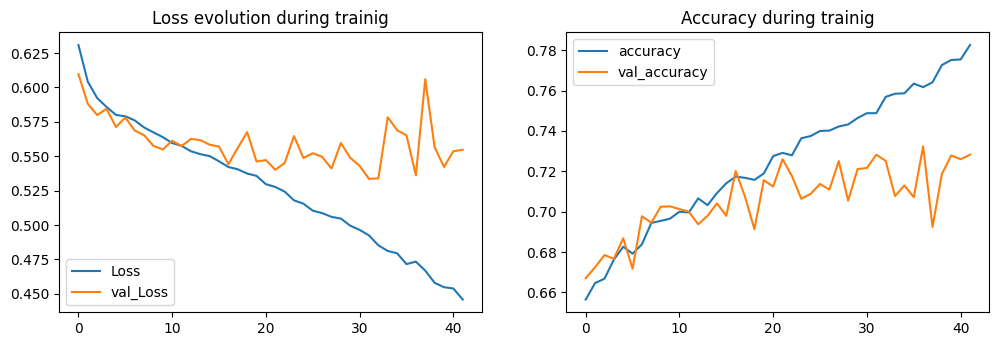

In [36]:
error_df = pd.DataFrame(model.history.history)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(error_df['loss'], label='Loss')
plt.plot(error_df['val_loss'], label='val_Loss')
plt.title('Loss evolution during trainig')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(error_df['accuracy'], label='accuracy')
plt.plot(error_df['val_accuracy'], label='val_accuracy')
plt.title('Accuracy during trainig')
plt.legend();

In [37]:
predictions = (model.predict(X_test) > 0.5).astype("int32")

166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 892us/step


In [38]:
from sklearn.metrics import classification_report, confusion_matrix

In [39]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.73      0.74      0.73      2701
           1       0.73      0.72      0.72      2609

    accuracy                           0.73      5310
   macro avg       0.73      0.73      0.73      5310
weighted avg       0.73      0.73      0.73      5310



In [40]:
px.imshow(confusion_matrix(y_test, predictions),
          text_auto = True,
          template = 'plotly_dark')